In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'


import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from matplotlib import gridspec
import matplotlib.path as mpath
from matplotlib import ticker, cm
import numpy as np
import netCDF4 as nc
import xarray as xr
import cmocean.cm as cmocean
import glob,os
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as mticker

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import gsw
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import intake 
import dask.distributed as dask
from dask.distributed import Client

figdir = '/g/data/x77/ps7863/figures/AABW_variability/'
degree = u'\N{DEGREE SIGN}'

In [2]:
from os import environ
environ["PYTHONWARNINGS"] = "ignore"

In [3]:
client = Client(threads_per_worker=1,memory_limit=0)
client.amm.start()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 24
Total threads: 24,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39331,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41851,Total threads: 1
Dashboard: /proxy/34393/status,Memory: 0 B
Nanny: tcp://127.0.0.1:42115,


In [4]:
iaf_cycle3 = '01deg_jra55v140_iaf_cycle3'
expt = '01deg_jra55v140_iaf_cycle3_antarctic_tracers'
catalog = intake.cat.access_nri

In [5]:
# lon_slice = slice(-70, 80)
lat_slice = slice(-82, -55)

degree =  u'\N{DEGREE SIGN}'

In [6]:
def yearly_mean(var):
    month_length = var.time.dt.days_in_month
    weights_month = (month_length.groupby('time.year') /
                     month_length.groupby('time.year').sum())
    var = (var * weights_month).groupby('time.year').sum()
    var = var.rename({'year': 'time'})
    return var

## Load necessary model variables

``ht`` for bathymetry contours

In [7]:
chunks_dict = {
    'time' : 36,
    'st_ocean' : 75,
    'yu_ocean' : '250Mb',
    'xu_ocean' : 360,
}

In [8]:
var='ht'
ht = catalog[iaf_cycle3].search(
    variable=var
).to_dask(
    threaded=False,
    xarray_open_kwargs = {            
    "decode_timedelta" : True}
)
ht = ht['ht']

ht = ht.sel(yt_ocean=lat_slice)
land_mask = np.squeeze(ht.values)
land_mask = land_mask * 0
land_mask[np.isnan(land_mask)] = 1
yt_ocean =ht.yt_ocean.values
xt_ocean =ht.xt_ocean.values
land_mask_masked = np.ma.masked_where((land_mask==0),land_mask)



land = xr.where(np.isnan(ht.rename('land')), 1, np.nan)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


In [9]:
shelf_mask = ht > 1000
shelf_mask = shelf_mask.astype(bool)
masked_shelf = shelf_mask.where(shelf_mask==0, np.nan)
shelf_mask = shelf_mask.where(shelf_mask==1, np.nan)
shelf_mask

<xarray.DataArray 'ht' (yt_ocean: 584, xt_ocean: 3600)> Size: 17MB
dask.array<where, shape=(584, 3600), dtype=float64, chunksize=(540, 720), chunktype=numpy.ndarray>
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 5kB -81.11 -81.07 -81.02 ... -55.07 -55.01

In [16]:
ht=ht.chunk({'xt_ocean': 360, 'yt_ocean': '200Mb'})
ht

<xarray.DataArray 'ht' (yt_ocean: 584, xt_ocean: 3600)> Size: 8MB
dask.array<rechunk-merge, shape=(584, 3600), dtype=float32, chunksize=(584, 360), chunktype=numpy.ndarray>
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 5kB -81.11 -81.07 -81.02 ... -55.07 -55.01
Attributes:
    long_name:      ocean depth on t-cells
    units:          m
    valid_range:    [-1.e+09  1.e+09]
    cell_methods:   time: point
    standard_name:  sea_floor_depth_below_geoid

## Load pre-saved model T, S

In [10]:
temp = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_cell/temp_bottom_1958-2018.nc', 
                      chunks={'time':12, 'yt_ocean': '250Mb', 'xt_ocean': 360})
# convert to dataarray 
temp = temp['__xarray_dataarray_variable__'] - 273.15

salt = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_cell/salt_bottom_1958-2018.nc', 
                      chunks={'time':12, 'yt_ocean': '250Mb', 'xt_ocean': 360})
salt = salt['__xarray_dataarray_variable__']

In [11]:
temp = temp.chunk({'time':'125Mb', 'yt_ocean': 584, 'xt_ocean': 360})

In [11]:
# calculate climatology and climatological seasonal range + seasonal range for each year

temp_clim = temp.groupby('time.month').mean('time')
temp_range = temp_clim.max('month') - temp_clim.min('month')
temp_range_yearly = temp.groupby('time.year').max('time') - temp.groupby('time.year').min('time')

salt_clim = salt.groupby('time.month').mean('time')
salt_range = salt_clim.max('month') - salt_clim.min('month')
salt_range_yearly = salt.groupby('time.year').max('time') - salt.groupby('time.year').min('time')

In [14]:
temp_clim

<xarray.DataArray 'temp' (month: 12, yt_ocean: 584, xt_ocean: 3600)> Size: 202MB
dask.array<transpose, shape=(12, 584, 3600), dtype=float64, chunksize=(12, 584, 360), chunktype=numpy.ndarray>
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 5kB -81.11 -81.07 -81.02 ... -55.07 -55.01
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

# Weddell moorings 

In [87]:
files = [
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_1989_deepest.nc', 
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_1990_deepest.nc',
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_1993_deepest.nc',
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_1996_deepest.nc', 
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_2005_deepest.nc',
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_2008_deepest.nc',
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_2011_deepest.nc',
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_2013_deepest.nc', 
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_2017_deepest.nc'
]

arrays = [xr.open_dataset(x) for x in files]


In [96]:
arrays_CT = [ds.CT.resample(time='1D').mean('time') for ds in arrays]
arrays_salt = [ds.salinity.resample(time='1D').mean('time') for ds in arrays]
arrays_temp = [ds.temperature.resample(time='1D').mean('time') for ds in arrays]

In [97]:
def merge_mooring_dataarrays(
    arrays,
    time_name="time",
    freq=None,
    overlap_reducer="median",   # 'median' | 'mean' | 'first' | 'last'
    assume_sorted=False,
):
    """
    Merge multiple DataArrays from the same location into a single continuous series.
    - arrays: list of xr.DataArray, each with a time coordinate.
    - freq: optional pandas offset alias (e.g., '5min', '1H'). If None, inferred.
    - overlap_reducer: how to combine duplicate timestamps after concat.
    """
    # 1) Concatenate along time (outer coords okay)
    da = xr.concat(arrays, dim=time_name, data_vars="all", coords="all", join="outer")

    # 2) Sort by time if needed
    if not assume_sorted:
        da = da.sortby(time_name)

    # 3) Collapse duplicates within overlaps
    if da.indexes is not None and time_name in da.indexes:
        # groupby exact timestamps and reduce
        if overlap_reducer in ("median", "mean"):
            func = getattr(xr.core.dataarray.DataArray, overlap_reducer)
            da = da.groupby(time_name).apply(func)
        elif overlap_reducer == "first":
            da = da.groupby(time_name).first()
        elif overlap_reducer == "last":
            da = da.groupby(time_name).last()
        else:
            raise ValueError("overlap_reducer must be one of 'median','mean','first','last'")

    # 4) If you want explicit NaNs in gaps, reindex to a regular grid
    # if freq is None:
    #     tindex = da.indexes[time_name]
    #     freq = _infer_freq_from_timeindex(tindex)

    full_time = pd.date_range(da[time_name].min().item(), da[time_name].max().item(), freq=freq)
    da_full = da.reindex({time_name: full_time})  # inserts NaNs for missing stamps

    return da_full


In [98]:
# Suppose you’ve already read each file and extracted a DataArray with .name = 'temperature'
# and a proper 'time' coordinate:
# da1, da2, da3 = ...

merged_temp = merge_mooring_dataarrays(arrays_temp, time_name="time", overlap_reducer="median", freq='1d')
# Now merged is a single DataArray with NaNs where redeployments had gaps.
merged_salt = merge_mooring_dataarrays(arrays_salt, time_name='time', overlap_reducer='median', freq='1d')

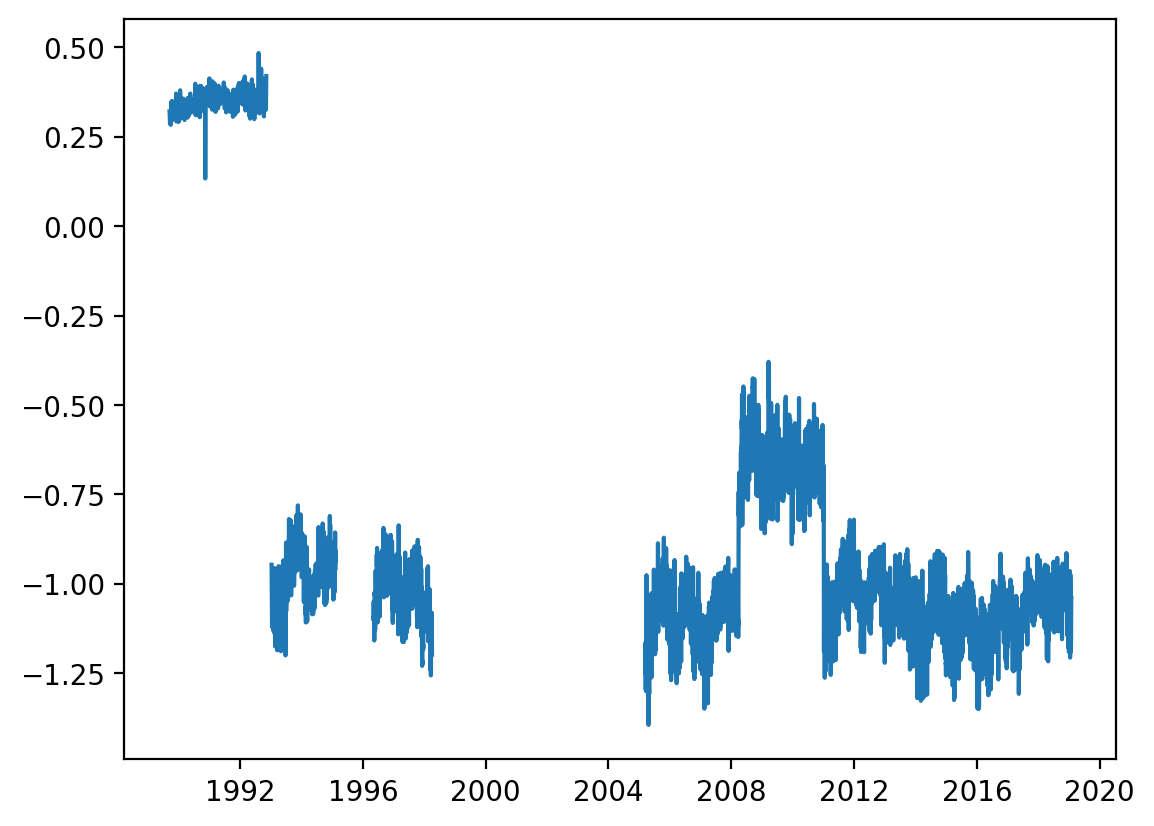

In [99]:
plt.plot(merged_temp.time, merged_temp)

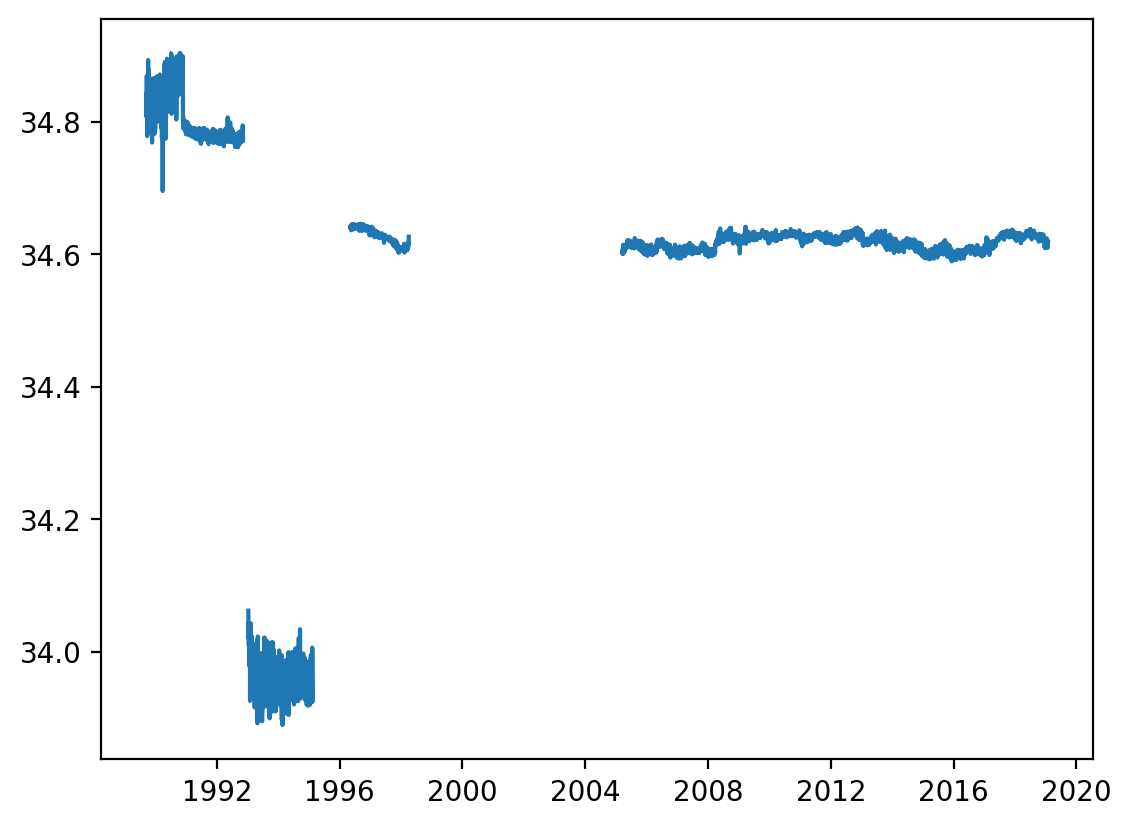

In [100]:
plt.plot(merged_salt.time, merged_salt)

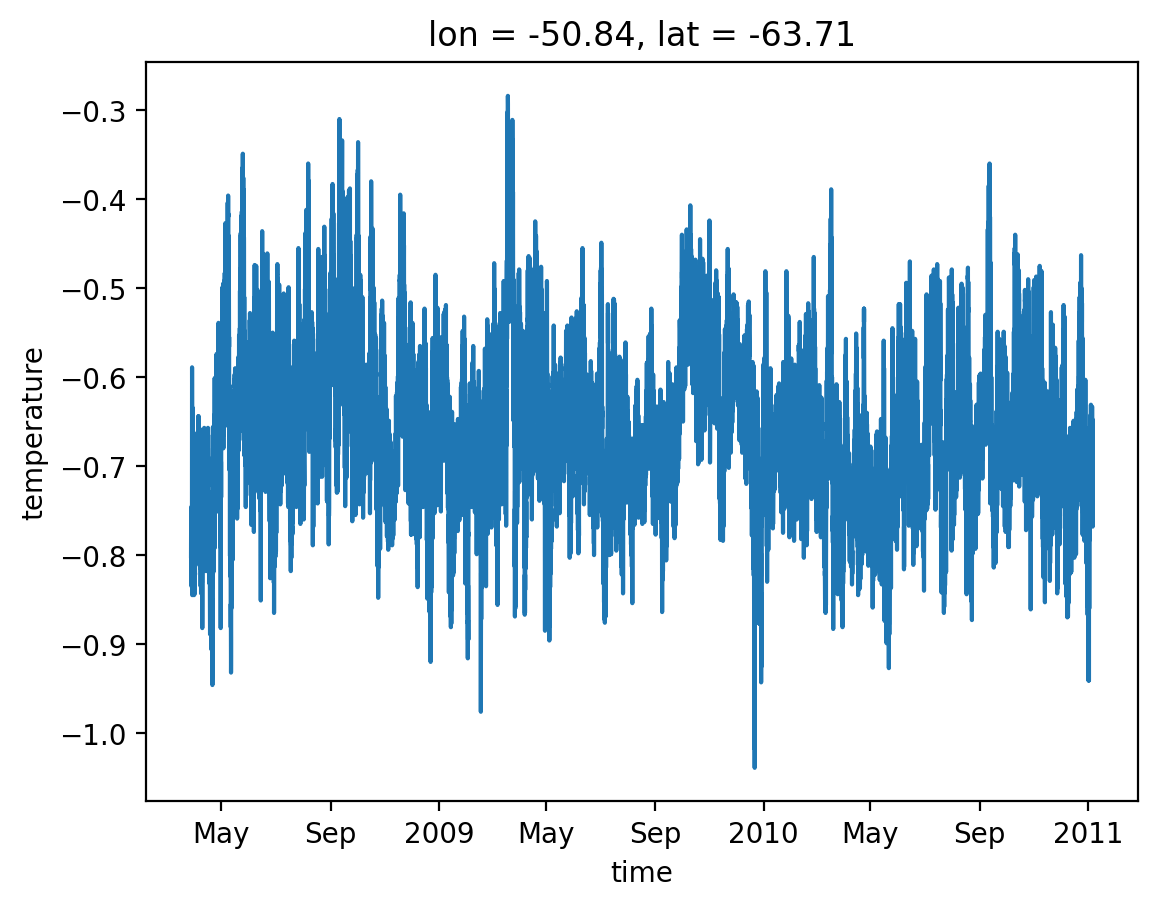

In [103]:
xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_2008_deepest.nc').temperature.plot()

In [111]:
files = [
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI217_1990_deepest.nc', 
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI217_1993_deepest.nc', 
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI217_2011_deepest.nc', 
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI217_2013_deepest.nc'
]

arrays = [xr.open_dataset(x) for x in files]
CT = [ds.CT.resample(time='1D').mean('time') for ds in arrays]
salt = [ds.salinity.resample(time='1D').mean('time') for ds in arrays]
temp = [ds.temperature.resample(time='1D').mean('time') for ds in arrays]

In [107]:
merged_CT = merge_mooring_dataarrays(arrays_CT, time_name="time", overlap_reducer="median", freq='1d')
# Now merged is a single DataArray with NaNs where redeployments had gaps.
merged_salt = merge_mooring_dataarrays(arrays_salt, time_name='time', overlap_reducer='median', freq='1d')

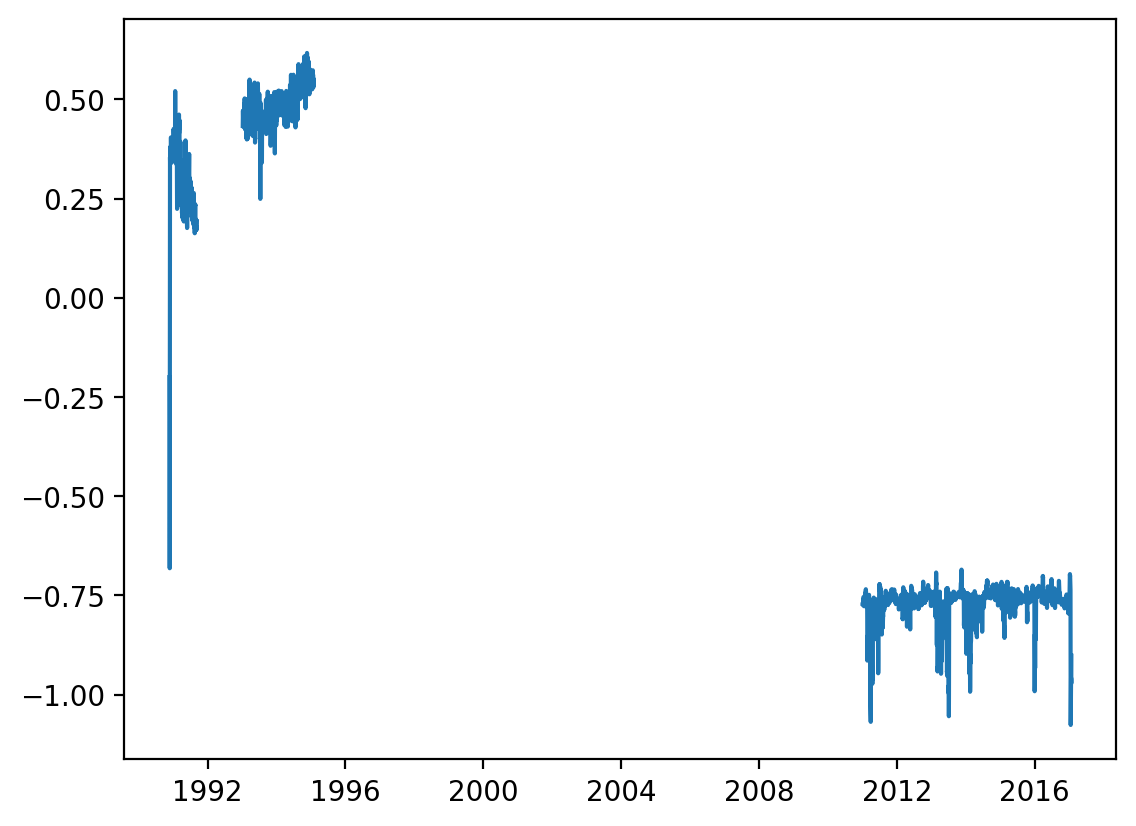

In [110]:
plt.plot(merged_CT.time,  merged_CT)

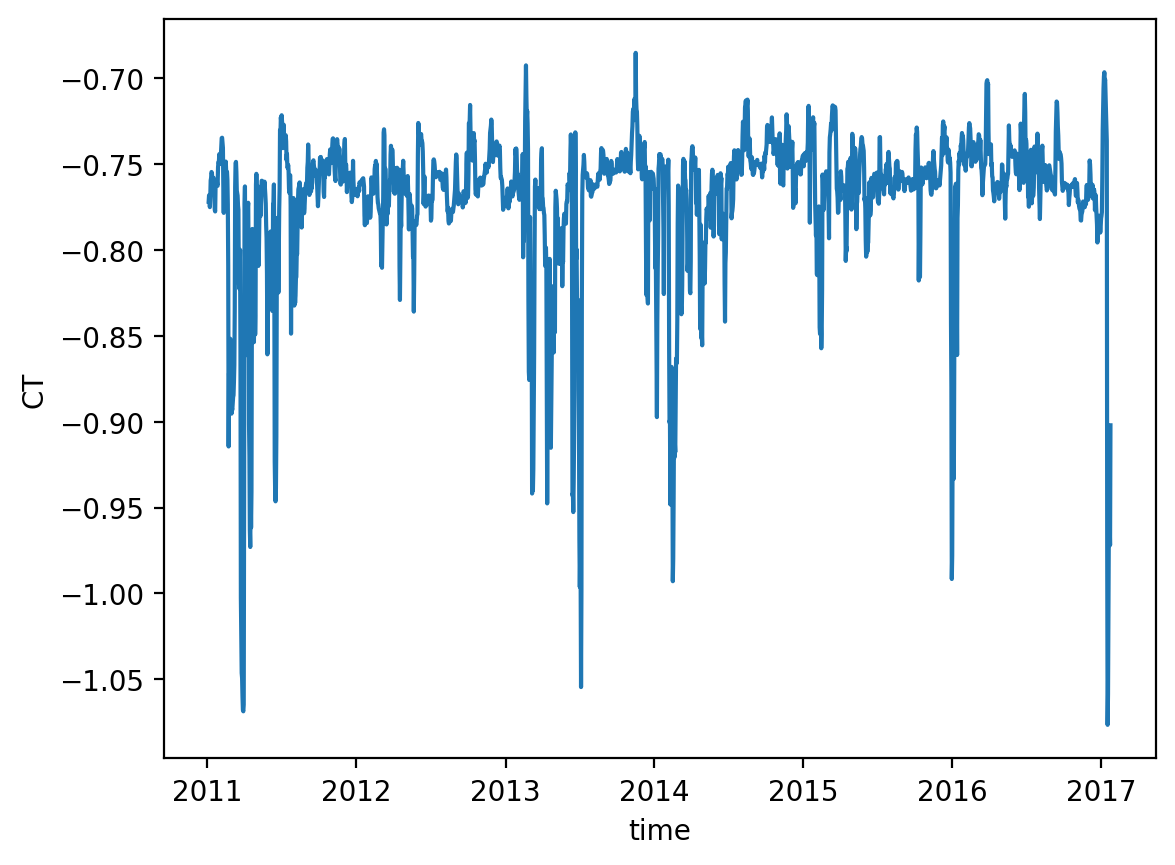

In [113]:
merged_CT.sel(time=slice('2011-01-01', '2018-01-01')).plot()

## Open mooring files for each region 

In [15]:
mertz2 = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/moorings/processed/Mertz98_polynya_2_processed.nc')

calm1 = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/moorings/processed/CALM_ca108_instr2_processed.nc')
calm2 = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/moorings/processed/CALM_ca108_instr5_processed.nc')

kombi = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/obs/KOMBI_2_filtered.nc')

awi217 = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI217_2008_processed.nc')
# calculate climatology and seasonal range (+ seasonal range for each year, for moorings > 1 year )
# monthly climatology 
mertz2_clim = mertz2.groupby('time.month').mean('time')
calm1_clim = calm1.groupby('time.month').mean('time') 
calm2_clim = calm2.groupby('time.month').mean('time') 
kombi_clim = kombi.groupby('time.month').mean('time')
awi_clim = awi217.groupby('time.month').mean('time')

# seasonal range 
mertz2_range = mertz2_clim.max('month') - mertz2_clim.min('month')
calm1_range = calm1_clim.max('month') - calm1_clim.min('month')
calm2_range = calm2_clim.max('month') - calm2_clim.min('month') 
kombi_range = kombi_clim.max('month') - kombi_clim.min('month') 
awi_range = awi_clim.max('month') - awi_clim.min('month')

# annual seasonal range 

# since data is hourly, we need to resample it to monthly time steps before calculating seasonal range in year-groups 
calm1_monthly = calm1.resample(time='1M').mean('time')
calm2_monthly = calm2.resample(time='1M').mean('time')
calm1_range_annual = calm1_monthly.groupby('time.year').max('time') -  calm1_monthly.groupby('time.year').min('time') 
calm2_range_annual = calm2_monthly.groupby('time.year').max('time') -  calm2_monthly.groupby('time.year').min('time') 


kombi_monthly = kombi.resample(time='1M').mean('time')
kombi_range_annual = kombi_monthly.resample(time='AS-FEB').max('time') - kombi_monthly.resample(time='AS-FEB').min('time')


awi_monthly = awi217.resample(time='1M').mean('time') 
awi_range_annual = awi_monthly.resample(time='AS-MAR').max('time') - awi_monthly.resample(time='AS-MAR').min('time')


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xarray/groupers.py:513: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xarray/groupers.py:513: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xarray/groupers.py:513: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xarray/groupers.py:513: FutureWarning: 'AS-FEB' is deprecated and will be removed in a future version, please use 'YS-FEB' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp65/public

In [8]:
mertz2

<xarray.Dataset> Size: 5MB
Dimensions:      (time: 113760)
Coordinates:
  * time         (time) datetime64[ns] 910kB 1998-04-16 ... 1999-05-15T23:53:...
Data variables:
    temperature  (time) float64 910kB ...
    pressure     (time) float64 910kB ...
    salinity     (time) float64 910kB ...
    SA           (time) float64 910kB ...
    CT           (time) float64 910kB ...
Attributes:
    Description:   Data from the deepest instrument of mooring Mertz98_polynya_2
    bottom_depth:  1180.0
    lat:           -65.8011
    lon:           142.9159
    start_date:    1998-04-16
    end_date:      1999-05-15

## Extract simulated temperature for the mooring locations

In [9]:
calm1


<xarray.Dataset> Size: 1MB
Dimensions:      (time: 26353)
Coordinates:
  * time         (time) datetime64[ns] 211kB 2008-01-22 ... 2011-01-24
Data variables:
    temperature  (time) float64 211kB ...
    pressure     (time) float64 211kB ...
    salinity     (time) float64 211kB ...
    SA           (time) float64 211kB ...
    CT           (time) float64 211kB ...
Attributes:
    Description:   Data from Instrument 2 of mooring CALM_ca108
    start_date:    2008-01-22
    end_date:      2011-01-24
    bottom_depth:  1753.0
    lon:           172.3042
    lat:           -71.4597

In [28]:
awi_clim.pressure1.mean().item(), awi_clim.pressure2.mean().item()

(4500.599999999834, 4450.099999999838)

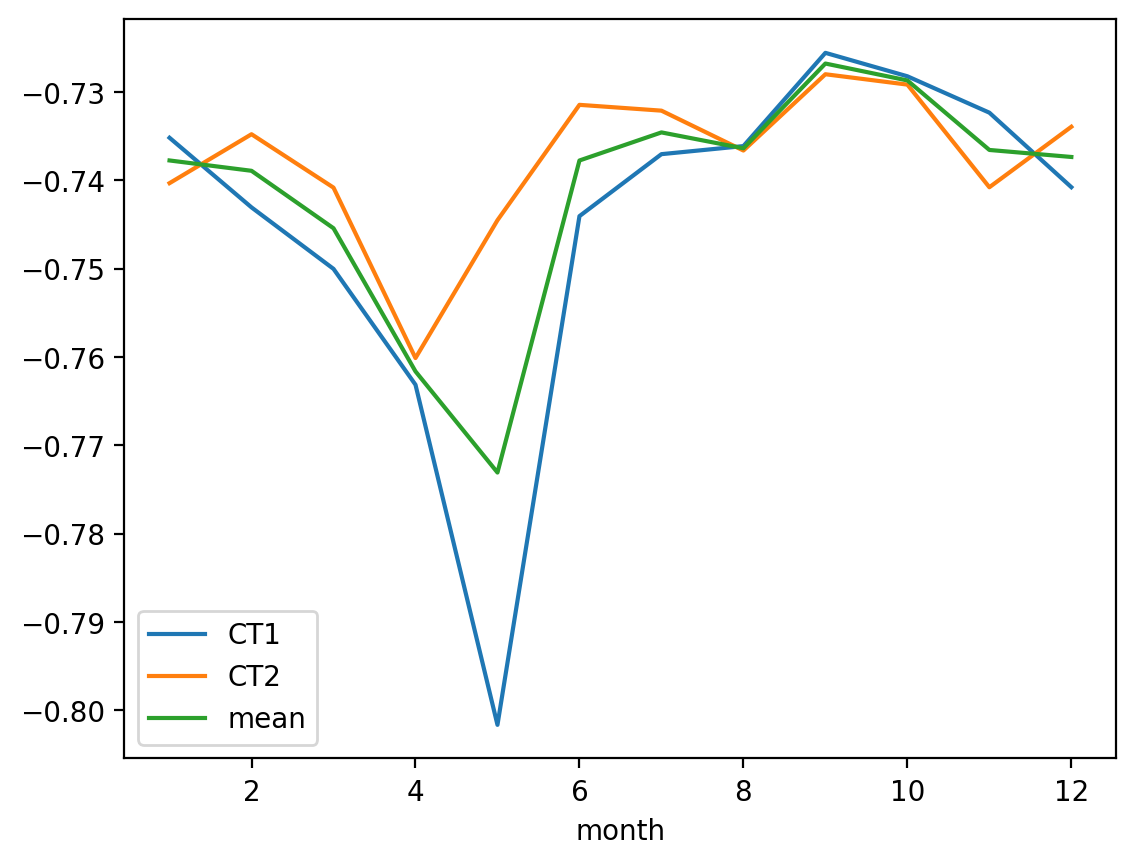

In [26]:
awi_clim.CT1.plot(label='CT1')
awi_clim.CT2.plot(label='CT2')
((awi_clim.CT1+awi_clim.CT2)/2).plot(label='mean')
plt.legend()

In [17]:
mertz2_moved = [139-360, -65.3]
model_mertz2_temp= temp.sel(xt_ocean=mertz2_moved[0],method='nearest').sel(yt_ocean=mertz2_moved[1],method='nearest')
model_mertz2_temp_clim = model_mertz2_temp.groupby('time.month').mean('time')
model_mertz2_temp_range_annual = model_mertz2_temp.groupby('time.year').max('time') - model_mertz2_temp.groupby('time.year').min('time')

# for CALM, I don't use digital subscript as both calm1 and calm2 datasets are from the same mooring (different instruments)
model_calm_temp = temp.sel(xt_ocean=calm1.lon-360, method='nearest').sel(yt_ocean=calm1.lat, method='nearest')
model_calm_temp_clim = model_calm_temp.groupby('time.month').mean('time')
model_calm_temp_range_annual = model_calm_temp.groupby('time.year').max('time') - model_calm_temp.groupby('time.year').min('time')


# KOMBI
model_kombi_temp = temp.sel(xt_ocean=kombi.longitude, method='nearest').sel(yt_ocean=kombi.latitude, method='nearest')
model_kombi_temp_clim = model_kombi_temp.groupby('time.month').mean('time')
model_kombi_temp_range_annual = model_kombi_temp.groupby('time.year').max('time') - model_kombi_temp.groupby('time.year').min('time')

# AWI
model_awi_temp = temp.sel(xt_ocean=awi217.lon, method='nearest').sel(yt_ocean=awi217.lat, method='nearest')
model_awi_temp_clim = model_awi_temp.groupby('time.month').mean('time')
model_awi_temp_range_annual = model_awi_temp.groupby('time.year').max('time') - model_awi_temp.groupby('time.year').min('time')

# std 
model_calm_temp_clim_std = model_calm_temp.groupby('time.month').std('time',ddof=1)
model_mertz2_temp_clim_std = model_mertz2_temp.groupby('time.month').std('time',ddof=1)
model_kombi_temp_clim_std = model_kombi_temp.groupby('time.month').std('time',ddof=1)
model_awi_temp_clim_std = model_awi_temp.groupby('time.month').std('time',ddof=1)

# compute month of minimum temp for every year 
model_calm_minT_month = model_calm_temp.groupby('time.year').apply(lambda x: x.argmin(dim='time')+1)
model_calm_minT_month = model_mertz2_temp.groupby('time.year').apply(lambda x: x.argmin(dim='time')+1)
model_calm_minT_month = model_kombi_temp.groupby('time.year').apply(lambda x: x.argmin(dim='time')+1)
model_awi_minT_month = model_awi_temp.groupby('time.year').apply(lambda x: x.argmin(dim='time')+1)

In [18]:
model_mertz2_temp_clim = model_mertz2_temp_clim.load()
model_mertz2_temp_range_annual = model_mertz2_temp_range_annual.load()

model_calm_temp_clim = model_calm_temp_clim.load()
model_calm_temp_range_annual = model_calm_temp_range_annual.load()

model_kombi_temp_clim = model_kombi_temp_clim.load()
model_kombi_temp_range_annual = model_kombi_temp_range_annual.load()

model_awi_temp_clim = model_awi_temp_clim.load()
model_awi_temp_range_annual = model_awi_temp_range_annual.load()

model_calm_temp_clim_std = model_calm_temp_clim_std.load()
model_mertz2_temp_clim_std = model_mertz2_temp_clim_std.load()
model_kombi_temp_clim_std = model_kombi_temp_clim_std.load()
model_awi_temp_clim_std = model_awi_temp_clim_std.load()


model_calm_minT_month = model_calm_minT_month.load()
model_calm_minT_month = model_calm_minT_month.load()
model_calm_minT_month = model_calm_minT_month.load()
model_awi_minT_month = model_awi_minT_month.load()

## Make Figure 

In [16]:
# Helper function used for visualization in the following examples
def identify_axes(ax_dict, fontsize=48):
    """
    Helper to identify the Axes in the examples below.

    Draws the label in a large font in the center of the Axes.

    Parameters
    ----------
    ax_dict : dict[str, Axes]
        Mapping between the title / label and the Axes.
    fontsize : int, optional
        How big the label should be.
    """
    kw = dict(ha="center", va="center", fontsize=fontsize, color="darkgrey")
    for k, ax in ax_dict.items():
        ax.text(0.5, 0.5, k, transform=ax.transAxes, **kw)

In [17]:
theta  = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.45
verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)


In [18]:
land_50m = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", edgecolor="black", facecolor="grey", linewidth=0.5
)

In [19]:
# To plot 1000-m contour
contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
shelf = contour_file['contour_masked_above']
yt_ocean = contour_file['yt_ocean']
xt_ocean = contour_file['xt_ocean']
# Mask values that are non-zero
shelf[np.where(shelf!=0)] = np.nan
shelf = shelf+1
shelf = np.nan_to_num(shelf)
shelf = xr.DataArray(shelf, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])

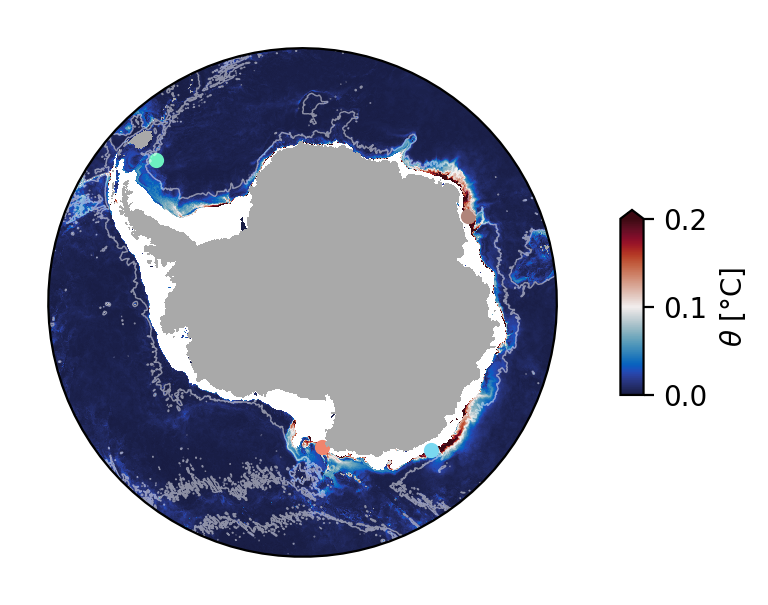

In [23]:
fig = plt.figure(1, figsize=(4,4))
ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo(), facecolor="darkgrey")
ax.set_boundary(circle, transform=ax.transAxes)
cmap=cmocean.balance

# Filled land 
land.plot.contourf(ax=ax, colors='darkgrey',
                   zorder=2,
                   transform=ccrs.PlateCarree(),
                   add_colorbar=False)
ax.contourf(shelf.xt_ocean, shelf.yt_ocean, shelf, [0.5, 1], transform=ccrs.PlateCarree(), colors='white')

temp_range.plot.pcolormesh(ax=ax, cmap=cmap,
                            vmin=0, vmax=0.2,
                            transform=ccrs.PlateCarree(),
                            cbar_kwargs={'orientation': 'vertical',
                                          'shrink': 0.25,
                                          'extend': 'max',
                                          'label': None,
                                          'aspect': 8, 
                                          'label': r'$\theta$ '+f'[{degree}C]'
                                         })

# Depth contours
ht.plot.contour(ax=ax, levels=[3500],
                colors='w', linewidths=[0.5], alpha=0.5,
                transform=ccrs.PlateCarree())

ax.scatter(model_awi_temp.xt_ocean, model_awi_temp.yt_ocean, s=20, marker='o', color=colors[0], transform=ccrs.PlateCarree())
ax.scatter(model_kombi_temp.xt_ocean, model_kombi_temp.yt_ocean, s=20, marker='o', color=colors[1], transform=ccrs.PlateCarree())
ax.scatter(model_mertz2_temp.xt_ocean, model_mertz2_temp.yt_ocean, s=20, marker='o', color=colors[2], transform=ccrs.PlateCarree())
ax.scatter(model_calm_temp.xt_ocean, model_calm_temp.yt_ocean, s=20, marker='o', color=colors[3], transform=ccrs.PlateCarree())


plt.tight_layout()

- Reduce white space (specify axes coordinates)
- Add subplot annotations
- Change colour-coding
- Change colours of obsrved seasonal cycle line and range dots according to the region colour


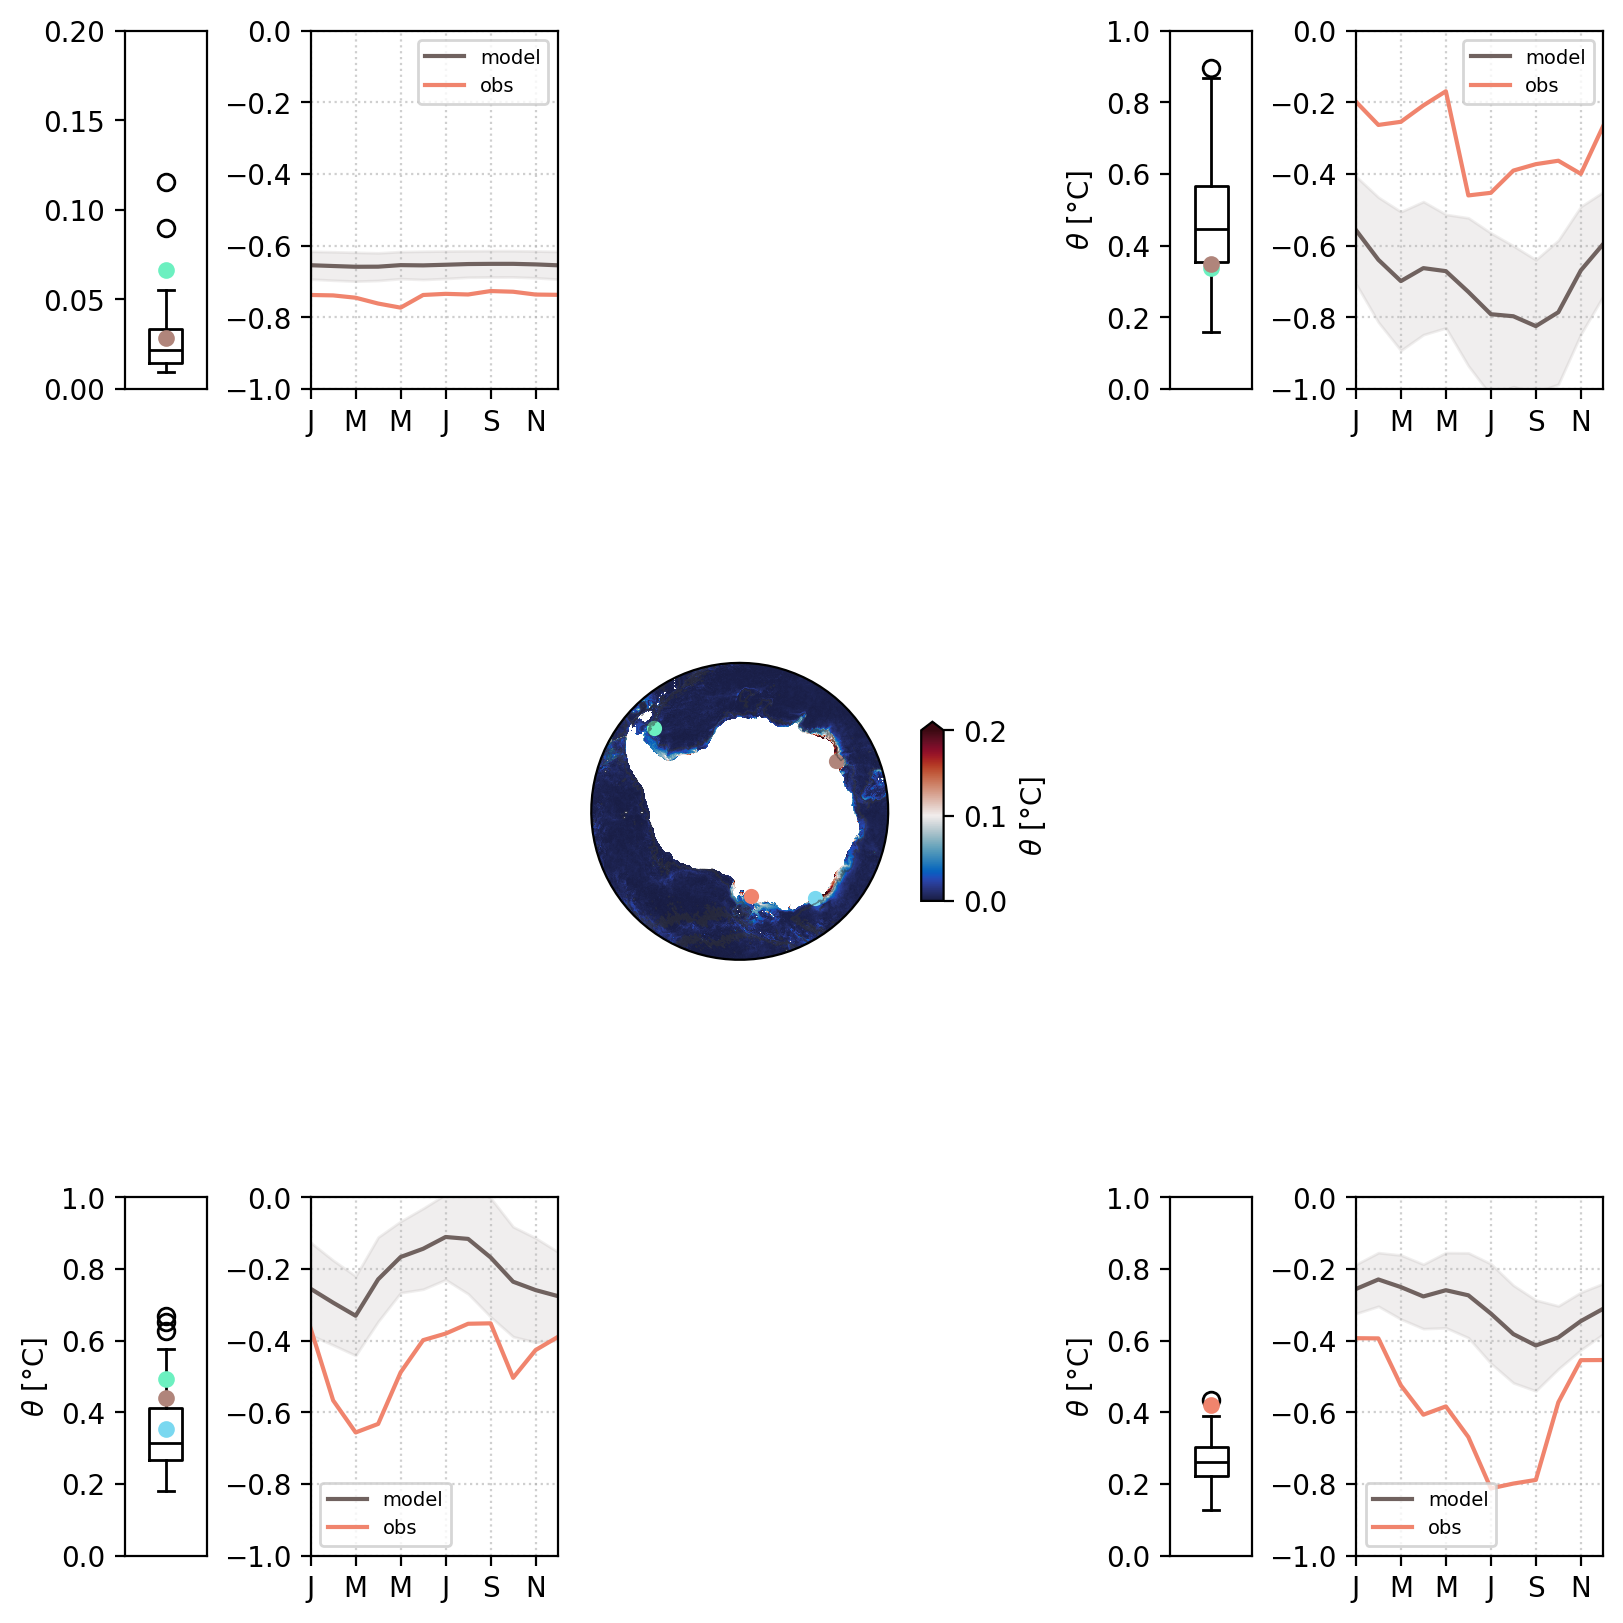

In [21]:
fig, axd = plt.subplot_mosaic(
    "ABBB....CDDD;....EEEE....;FGGG....HIII",
    per_subplot_kw={
        "E": {"projection": ccrs.SouthPolarStereo()}, #
    },
    height_ratios=[0.5,1,0.5],
    figsize=(8,8),
    constrained_layout=True
)
# identify_axes(axd)

colors = ['#6CF0C0',  '#B0857B', '#7AD8F0', '#F0846D',  '#C2B78B', '#70625F']
model_color =  colors[-1]
obs_color = colors[3]
boxwidth = 0.4


axd['A'].axes.get_xaxis().set_visible(False)
axd['E'].set_boundary( circle, transform=axd['E'].transAxes)


# Coastline
# land.fillna(0).plot.contour(ax=axd['E'], colors='k', levels=[0, 1],
#                             transform=ccrs.PlateCarree(),
#                             add_colorbar=False)

# Depth contours
ht.plot.contour(ax=axd['E'], levels=[3500],
                colors='0.2', linewidths=[0.5], alpha=0.5,
                transform=ccrs.PlateCarree())
cmap=cmocean.balance
temp_range.plot.pcolormesh(ax=axd['E'], cmap=cmap,
                           vmin=0, vmax=0.2,
                            transform=ccrs.PlateCarree(),
                            cbar_kwargs={'orientation': 'vertical',
                                         'shrink': 0.25,
                                         'extend': 'max',
                                         'label': None,
                                         'aspect': 8, 
                                         'label': r'$\theta$ '+f'[{degree}C]'
                                        }) 
# Filled land 
land.plot.contourf(ax=axd['E'], colors='darkgrey',
                   # zorder=2,
                   transform=ccrs.PlateCarree(),
                   add_colorbar=False)

axd['E'].contourf(shelf.xt_ocean, shelf.yt_ocean, shelf, [0.5, 1], transform=ccrs.PlateCarree(), colors='white')
axd['E'].scatter(model_awi_temp.xt_ocean, model_awi_temp.yt_ocean, s=20, marker='o', color=colors[0], transform=ccrs.PlateCarree())
axd['E'].scatter(model_kombi_temp.xt_ocean, model_kombi_temp.yt_ocean, s=20, marker='o', color=colors[1], transform=ccrs.PlateCarree())
axd['E'].scatter(model_mertz2_temp.xt_ocean, model_mertz2_temp.yt_ocean, s=20, marker='o', color=colors[2], transform=ccrs.PlateCarree())
axd['E'].scatter(model_calm_temp.xt_ocean, model_calm_temp.yt_ocean, s=20, marker='o', color=colors[3], transform=ccrs.PlateCarree())


##### WEDDELL SEA #########
# Weddell Sea: box plot: temp range 
bp = axd['A'].boxplot(model_awi_temp_range_annual, widths=boxwidth)
axd['A'].set_ylim(0,0.2)
for i, c in zip((awi_range_annual.CT1+awi_range_annual.CT2)/2, colors):
    axd['A'].plot(1, i, marker='o', markersize=5, c=c)
for median in bp['medians']:
    median.set_color('black')


# Weddell Sea : climatology plot 
axd['B'].plot(model_awi_temp_clim.month, model_awi_temp_clim, c=model_color, label='model')
axd['B'].fill_between(model_awi_temp_clim.month,
                     model_awi_temp_clim+model_awi_temp_clim_std, 
                     model_awi_temp_clim-model_awi_temp_clim_std,
                     alpha=0.1, 
                     color=model_color)
axd['B'].plot(awi_clim.month, (awi_clim.CT1+awi_clim.CT2)/2, c=obs_color, label='obs')

##### PRYDZ BAY #########
# Prydz Bay: box plot: temp range 
bp = axd['C'].boxplot(model_kombi_temp_range_annual, widths=boxwidth)
for i, c in zip(kombi_range_annual.CT, colors):
    axd['C'].plot(1, i, marker='o', markersize=5, c=c)
for median in bp['medians']:
    median.set_color('black')

# Prydz Bay: climatology plot
axd['D'].plot(model_kombi_temp_clim.month, model_kombi_temp_clim, c=model_color, label='model')
axd['D'].fill_between(model_kombi_temp_clim.month, 
                        model_kombi_temp_clim +
                        model_kombi_temp_clim_std,
                        model_kombi_temp_clim -
                        model_kombi_temp_clim_std,
                      alpha=0.1,
                      color=model_color
)
axd['D'].plot(kombi_clim.month, kombi_clim.CT, c=obs_color, label='obs')
    

##### ROSS SEA ##########
# Ross Sea: box plot: temp range 
bp=axd['F'].boxplot(model_calm_temp_range_annual, widths=boxwidth)
# axd['F'].set_ylabel(r'$\theta$ '+ f'[{degree}C]')
for i, c in zip(calm1_range_annual.CT[:-1], colors):
    axd['F'].plot(1, i, marker='o', markersize=5, c=c)
for median in bp['medians']:
    median.set_color('black')

# Ross Sea: climatology plot 
axd['G'].plot(model_calm_temp_clim.month, model_calm_temp_clim, c=model_color, label='model')
axd['G'].fill_between(model_calm_temp_clim.month,
                      model_calm_temp_clim + 
                     model_calm_temp_clim_std, 
                     model_calm_temp_clim - 
                     model_calm_temp_clim_std, 
                     alpha=0.1, 
                     color=model_color)
axd['G'].plot(calm1_clim.month, calm1_clim.CT, c=obs_color, label='obs')


####### Adélie Land ############
# Adélie Land: box plot: temp range 
bp = axd['H'].boxplot(model_mertz2_temp_range_annual, widths=boxwidth)
axd['H'].plot(1, mertz2_range.CT, marker='o', markersize=5, c=obs_color)
for median in bp['medians']:
    median.set_color('black')

# Adélie LandL climatology : line plot 
axd['I'].plot(model_mertz2_temp_clim.month, model_mertz2_temp_clim, c=model_color, label='model')
axd['I'].fill_between(model_mertz2_temp_clim.month, 
                      model_mertz2_temp_clim + 
                     model_mertz2_temp_clim_std, 
                     model_mertz2_temp_clim - 
                     model_mertz2_temp_clim_std,
                     alpha=0.1,
                     color=model_color)
axd['I'].plot(mertz2_clim.month, mertz2_clim.CT, c=obs_color, label='obs')

lineplots = [axd['B'], axd['D'], axd['G'], axd['I']]
for p in lineplots:
    p.legend(fontsize=7)
    p.set_xticks([1, 3, 5, 7, 9, 11])
    p.set_xticklabels(['J', 'M', 'M', 'J', 'S', 'N'], fontsize=10)
    p.grid(axis='both', alpha=0.6, linestyle=':')
    p.set_ylim(-1,0)
    p.set_xlim(1,12)

boxplots = [axd['C'], axd['F'], axd['H']]
for p in boxplots:
    p.set_ylabel(r'$\theta$ '+ f'[{degree}C]')
    p.set_ylim(0,1)
    p.axes.get_xaxis().set_visible(False)

# plt.savefig(f'{figdir}/model_obs_comparison.png', dpi=300)
    

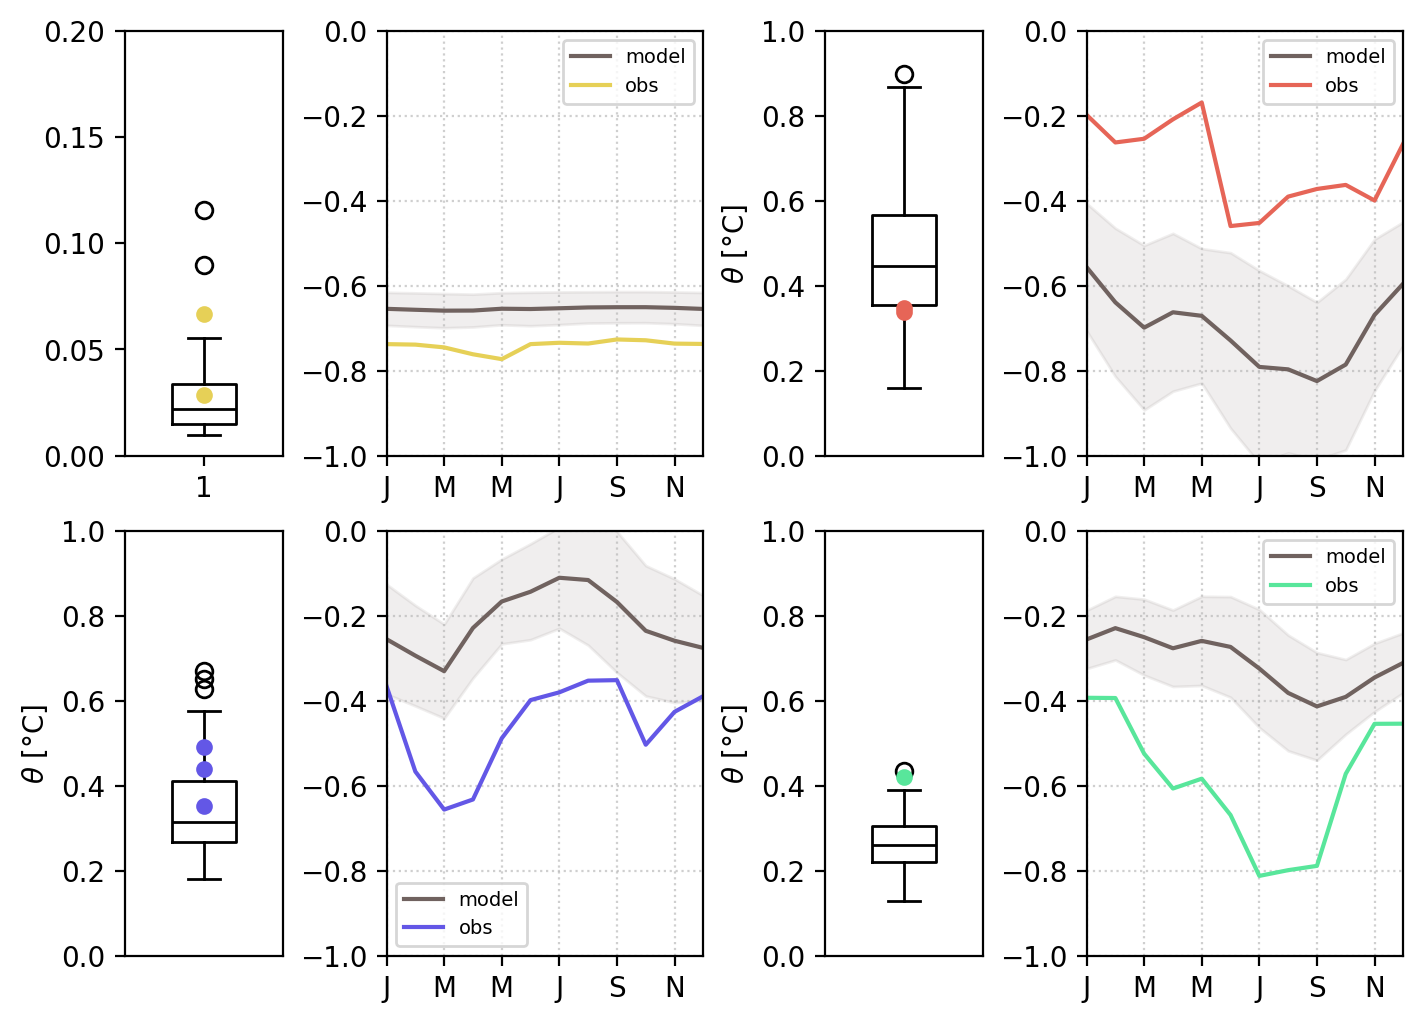

In [28]:
fig, axd = plt.subplot_mosaic(
    "ABBCDD;FGGHII",
    figsize=(7,5),
    constrained_layout=True
)

colors = ['#6CF0C0',  '#B0857B', '#7AD8F0', '#F0846D',  '#C2B78B', '#70625F']
model_color =  colors[-1]
obs_color = colors[3]
boxwidth = 0.4

c_weddell = '#E6D057'
c_prydz = '#E66557'
c_adelie = '#58E69B'
c_ross = '#6357E6'

##### WEDDELL SEA #########
# Weddell Sea: box plot: temp range 
bp = axd['A'].boxplot(model_awi_temp_range_annual, widths=boxwidth)
axd['A'].set_ylim(0,0.2)
for i in ((awi_range_annual.CT1+awi_range_annual.CT2)/2):
    axd['A'].plot(1, i, marker='o', markersize=5, c=c_weddell)
for median in bp['medians']:
    median.set_color('black')


# Weddell Sea : climatology plot 
axd['B'].plot(model_awi_temp_clim.month, model_awi_temp_clim, c=model_color, label='model')
axd['B'].fill_between(model_awi_temp_clim.month,
                     model_awi_temp_clim+model_awi_temp_clim_std, 
                     model_awi_temp_clim-model_awi_temp_clim_std,
                     alpha=0.1, 
                     color=model_color)
axd['B'].plot(awi_clim.month, (awi_clim.CT1+awi_clim.CT2)/2, c=c_weddell, label='obs')

##### PRYDZ BAY #########
# Prydz Bay: box plot: temp range 
bp = axd['C'].boxplot(model_kombi_temp_range_annual, widths=boxwidth)
for i in kombi_range_annual.CT:
    axd['C'].plot(1, i, marker='o', markersize=5, c=c_prydz)
for median in bp['medians']:
    median.set_color('black')

# Prydz Bay: climatology plot
axd['D'].plot(model_kombi_temp_clim.month, model_kombi_temp_clim, c=model_color, label='model')
axd['D'].fill_between(model_kombi_temp_clim.month, 
                        model_kombi_temp_clim +
                        model_kombi_temp_clim_std,
                        model_kombi_temp_clim -
                        model_kombi_temp_clim_std,
                      alpha=0.1,
                      color=model_color
)
axd['D'].plot(kombi_clim.month, kombi_clim.CT, c=c_prydz, label='obs')

##### ROSS SEA ##########
# Ross Sea: box plot: temp range 
bp=axd['F'].boxplot(model_calm_temp_range_annual, widths=boxwidth)
# axd['F'].set_ylabel(r'$\theta$ '+ f'[{degree}C]')
for i in calm1_range_annual.CT[:-1]:
    axd['F'].plot(1, i, marker='o', markersize=5, c=c_ross)
for median in bp['medians']:
    median.set_color('black')

# Ross Sea: climatology plot 
axd['G'].plot(model_calm_temp_clim.month, model_calm_temp_clim, c=model_color, label='model')
axd['G'].fill_between(model_calm_temp_clim.month,
                      model_calm_temp_clim + 
                     model_calm_temp_clim_std, 
                     model_calm_temp_clim - 
                     model_calm_temp_clim_std, 
                     alpha=0.1, 
                     color=model_color)
axd['G'].plot(calm1_clim.month, calm1_clim.CT, c=c_ross, label='obs')


####### Adélie Land ############
# Adélie Land: box plot: temp range 
bp = axd['H'].boxplot(model_mertz2_temp_range_annual, widths=boxwidth)
axd['H'].plot(1, mertz2_range.CT, marker='o', markersize=5, c=c_adelie)
for median in bp['medians']:
    median.set_color('black')

# Adélie LandL climatology : line plot 
axd['I'].plot(model_mertz2_temp_clim.month, model_mertz2_temp_clim, c=model_color, label='model')
axd['I'].fill_between(model_mertz2_temp_clim.month, 
                      model_mertz2_temp_clim + 
                     model_mertz2_temp_clim_std, 
                     model_mertz2_temp_clim - 
                     model_mertz2_temp_clim_std,
                     alpha=0.1,
                     color=model_color)
axd['I'].plot(mertz2_clim.month, mertz2_clim.CT, c=c_adelie, label='obs')

lineplots = [axd['B'], axd['D'], axd['G'], axd['I']]
for p in lineplots:
    p.legend(fontsize=7)
    p.set_xticks([1, 3, 5, 7, 9, 11])
    p.set_xticklabels(['J', 'M', 'M', 'J', 'S', 'N'], fontsize=10)
    p.grid(axis='both', alpha=0.6, linestyle=':')
    p.set_ylim(-1,0)
    p.set_xlim(1,12)
boxplots = [axd['C'], axd['F'], axd['H']]
for p in boxplots:
    p.set_ylabel(r'$\theta$ '+ f'[{degree}C]')
    p.set_ylim(0,1)
    p.axes.get_xaxis().set_visible(False)
plt.savefig(f'{figdir}/model_obs_comparison.png', dpi=300)


In [18]:
# Load data
rsbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_200m/RSBW_range_1968-2018.nc')
albw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_200m/ALBW_range_1968-2018.nc')
wsbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_200m/WSBW_range_1968-2018.nc')
pbbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_200m/PBBW_range_1968-2018.nc')

rsbw_range = rsbw_range['RSBW_range']
albw_range = albw_range['ALBW_range']
wsbw_range = wsbw_range['WSBW_range']
pbbw_range = pbbw_range['PBBW_range']

In [21]:
land_50m = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", edgecolor="black", facecolor="grey", linewidth=0.5
)

In [19]:
# Define projection regions with correct orientation
regions = {
    "Ross": {
        "midlon": -215, "minlon": -250, "maxlon": -180,
        "minlat": -76, "maxlat": -60
    },
    "Weddell": {
        "midlon": -40, "minlon": -60, "maxlon": -20,
        "minlat": -76, "maxlat": -60
    },
    "Adelie": {
        "midlon": -230, "minlon": -250, "maxlon": -210,
        "minlat": -70, "maxlat": -60
    },
    "Prydz": {
        "midlon": 55, "minlon": 35, "maxlon": 75,
        "minlat": -70, "maxlat": -60
    }
}

In [30]:
# To plot 1000-m contour
contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
shelf = contour_file['contour_masked_above']
yt_ocean = contour_file['yt_ocean']
xt_ocean = contour_file['xt_ocean']
# Mask values that are non-zero
shelf[np.where(shelf!=0)] = np.nan
shelf = shelf+1
shelf = np.nan_to_num(shelf)
shelf = xr.DataArray(shelf, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])

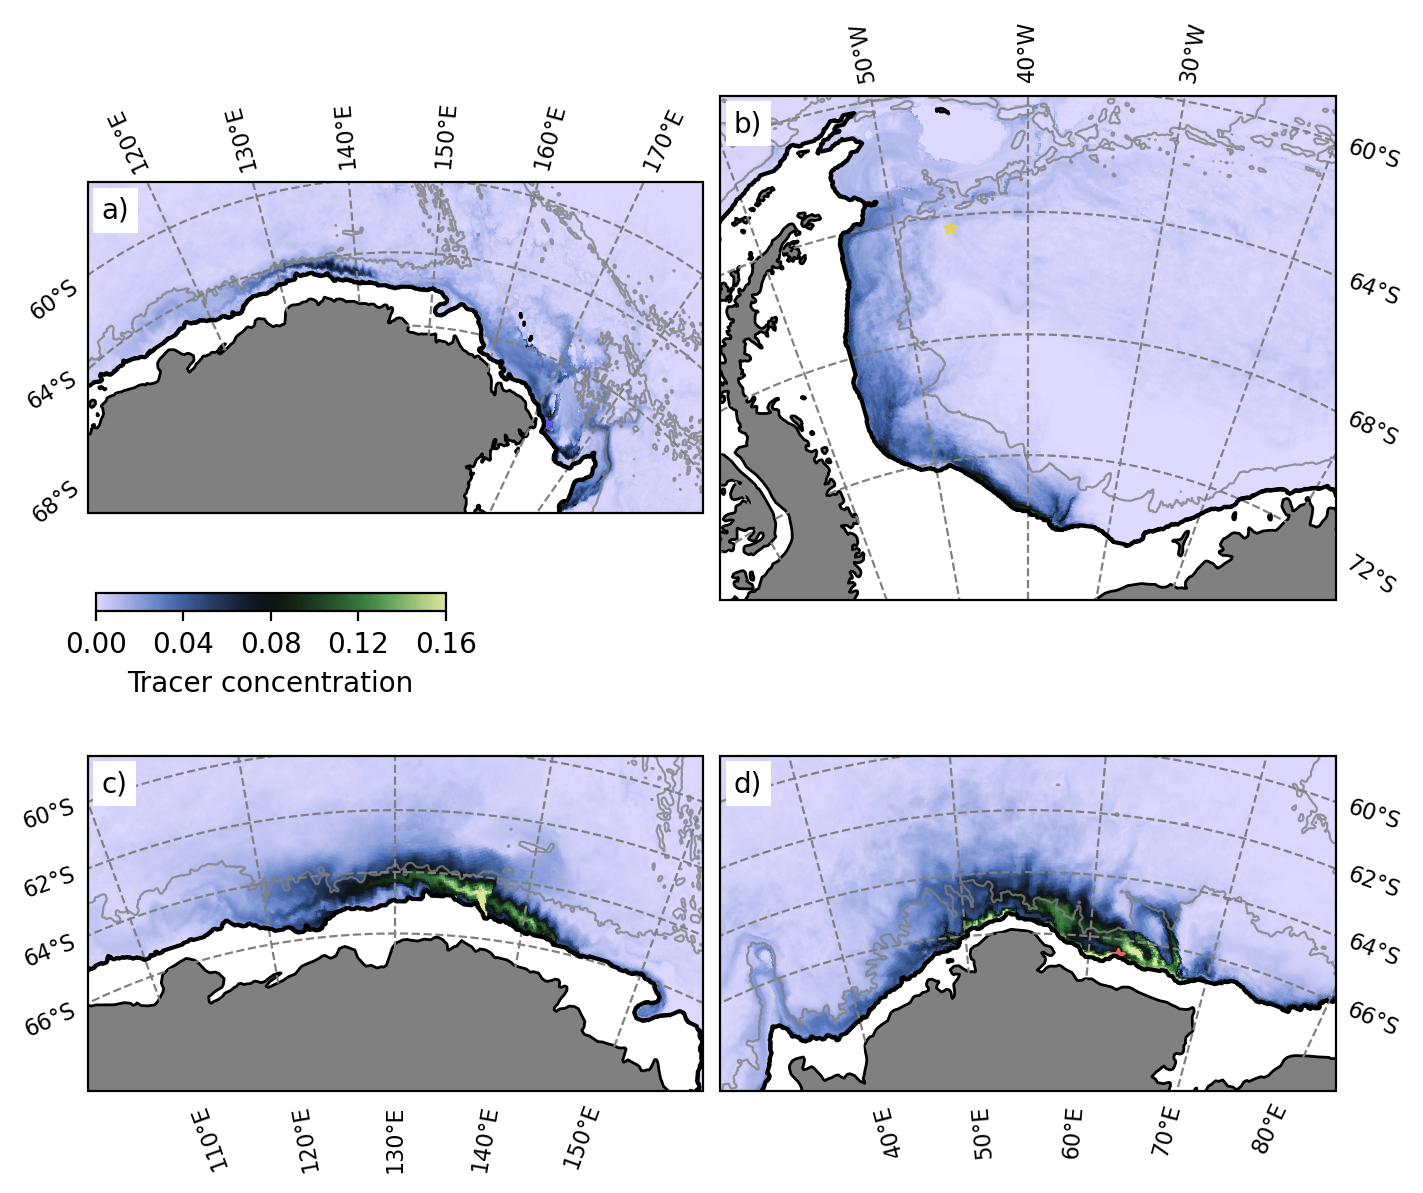

In [34]:
# Set up figure and GridSpec (2 rows x 3 columns)
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig)
norm = mcolors.TwoSlopeNorm(vmin=1, vcenter=6, vmax=12)
# cmap = cmocean.cm.diff
cmap =  cmcrameri.cm.tofino
alpha = 1

c_weddell = '#E6D057'
c_prydz = '#E66557'
c_adelie = '#58E69B'
c_ross = '#6357E6'

# Map region to subplot position (row, col)
subplot_positions = {
    "Ross":  (0, 0),  # Span 2 columns
    "Weddell": (0, 1),
    "Adelie":  (1, 0),
    "Prydz":   (1, 1)
}
fontsize=10
mask_color = 'linen'
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.08, vmax=0.16)
# Plot each region
for name, pos in subplot_positions.items():
    r = regions[name]
    proj = ccrs.Stereographic(central_latitude=-90, central_longitude=r["midlon"])
    ax = fig.add_subplot(gs[pos], projection=proj)

    ax.add_feature(land_50m)
    ax.coastlines(resolution="50m")
    ax.set_extent([r["minlon"], r["maxlon"], r["minlat"], r["maxlat"]], crs=ccrs.PlateCarree())
    gl=ax.gridlines(draw_labels=True, linestyle='--', color='grey', x_inline=False, y_inline=False)
    ax.spines['geo'].set_visible(True)
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.ylocator = LatitudeLocator()
    gl.xlocator = LongitudeLocator()
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    if name=='Ross':
        pc=ax.pcolormesh(rsbw_range.xt_ocean+360, rsbw_range.yt_ocean, rsbw_range, cmap=cmap, norm=norm, alpha=alpha, transform=ccrs.PlateCarree())
        ax.annotate(
        'a)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.bottom_labels = False
        gl.right_labels = False
        gl.xlocator = mticker.FixedLocator([120, 130, 140, 150, 160, 170, 180])
        gl.ylocator = mticker.FixedLocator([-68, -64, -60])
        ax.scatter(calm1.lon, calm1.lat, s=20, marker='*', color=c_ross, transform=ccrs.PlateCarree())

    if name=='Weddell':
        ax.pcolormesh(wsbw_range.xt_ocean+360, wsbw_range.yt_ocean, wsbw_range, cmap=cmap, norm=norm,  alpha=alpha,transform=ccrs.PlateCarree()) 
        ax.annotate(
        'b)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.bottom_labels = False
        gl.left_labels = False
        gl.ylocator = mticker.FixedLocator([-72, -68, -64, -60]) 
        ax.scatter(awi217.lon, awi217.lat, s=20, marker='*', color=c_weddell, transform=ccrs.PlateCarree())


    if name=='Adelie':
        ax.pcolormesh(albw_range.xt_ocean+360, albw_range.yt_ocean, albw_range, cmap=cmap, norm=norm,  alpha=alpha,transform=ccrs.PlateCarree())
        ax.annotate(
        'c)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.right_labels = False
        gl.ylocator = mticker.FixedLocator([-66, -64, -62, -60])
        gl.top_labels = False
        ax.scatter(mertz2.lon, mertz2.lat, s=20, marker='*', color=c_adelie, transform=ccrs.PlateCarree(), zorder=0)
        ax.scatter(mertz2_moved[0], mertz2_moved[1], s=20, marker='o', color=c_adelie, transform=ccrs.PlateCarree(), zorder=0)

        
    if name=='Prydz':        
        ax.pcolormesh(pbbw_range.xt_ocean+360, pbbw_range.yt_ocean, pbbw_range, cmap=cmap, norm=norm, alpha=alpha, transform=ccrs.PlateCarree())
        ax.annotate(
        'd)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.xlocator = mticker.FixedLocator([40, 50, 60, 70, 80])
        gl.ylocator = mticker.FixedLocator([-66, -64, -62, -60])
        gl.left_labels = False
        gl.top_labels = False
        ax.scatter(kombi.longitude, kombi.latitude, s=20, marker='*', color=c_prydz, transform=ccrs.PlateCarree())


    ax.contour(shelf.xt_ocean, shelf.yt_ocean,shelf,
                [0.5],
                colors = 'k',
                linewidths = 1.5,
                transform=ccrs.PlateCarree())

    ax.contour(ht.xt_ocean, ht.yt_ocean, ht,
                    levels=[3500],
                    colors='grey',
                    linewidths=.8,
                    alpha=.8,
                    transform=ccrs.PlateCarree())
    ax.contourf(shelf.xt_ocean, shelf.yt_ocean, shelf, [0.5, 1], transform=ccrs.PlateCarree(), colors='white')

cbar_ax1 = fig.add_axes([0.06, 0.5, 0.25, 0.015])  # [left, bottom, width, height]

cbar1 = plt.colorbar(pc, cax=cbar_ax1,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 0.04, 0.08, 0.12, 0.16],
                     location='bottom'
                    )
# cbar1.tick_params(labelsize=10)
cbar1.set_label('Tracer concentration', fontsize=10)

figdir = '/g/data/x77/ps7863/figures/figures_access_workshop/'

plt.savefig(f'{figdir}/tracer_seasonal_range_1968-2018.png', dpi=300, bbox_inches='tight')


In [33]:
kombi

<xarray.Dataset> Size: 5MB
Dimensions:      (time: 103623)
Coordinates:
  * time         (time) datetime64[ns] 829kB 2021-02-21T16:20:00 ... 2023-02-...
Data variables:
    temperature  (time) float64 829kB ...
    salinity     (time) float64 829kB ...
    pressure     (time) float64 829kB ...
    SA           (time) float64 829kB ...
    CT           (time) float64 829kB ...
Attributes:
    station:    KOMBI_2
    latitude:   -66.52
    longitude:  62.45
    depth:      1730
    source:     CTD mooring